In [1]:
# uv add langchain_community pymupdf
from langchain_community.document_loaders import PyMuPDFLoader

# 문서 로드
loader = PyMuPDFLoader(r"..\data\Employee_Benefits_Guide_2026_v1.pdf")
documents = loader.load()

In [3]:
print(documents[0].page_content)

2026 년 테크노빌드 주식회사(TechnoBuild) 임직원 
통합 가이드북 
문서 번호: TB-HR-2026-001 (Rev 5.0) 
발행일: 2026 년 1 월 15 일 
적용 대상: 테크노빌드 전 임직원 (정규직, 계약직, 파견직 포함) 
주관 부서: 인사문화본부 (HR Culture Division) 
보안 등급: 대외비 (Internal Use Only) 
 
[목 차] 
1. 회사 개요 (Company Overview) 
o 1.1 CEO 인사말 
o 1.2 기업 미션 및 비전 
o 1.3 핵심 가치 : T-SPIRIT 
o 1.4 조직도 및 본부 소개 
2. 인사 및 평가 제도 (HR System) 
o 2.1 직급 및 호칭 체계 
o 2.2 승진 포인트 제도 (Tech-Point) 
o 2.3 성과 평가 (T-MBO) 프로세스 
o 2.4 전문직군 전환 제도 (Dual Ladder) 
3. 근무 및 복무 관리 (Work & Duty) 
o 3.1 표준 근무 시간 및 유연 근무제 
o 3.2 생산직 교대 근무 (T-Shift) 운영 규정 
o 3.3 시간외 근무 및 특근 신청 절차 
o 3.4 휴가 제도 상세 (연차, 공가, 병가, 청원 휴가 등) 
o 3.5 하이브리드 및 재택 근무 가이드 (Hybrid Work Policy)


In [4]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# 문서 분할
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)
splitted_documents = text_splitter.split_documents(documents)

In [5]:
len(splitted_documents)

44

In [6]:
print(splitted_documents[0].page_content)

2026 년 테크노빌드 주식회사(TechnoBuild) 임직원 
통합 가이드북 
문서 번호: TB-HR-2026-001 (Rev 5.0) 
발행일: 2026 년 1 월 15 일 
적용 대상: 테크노빌드 전 임직원 (정규직, 계약직, 파견직 포함) 
주관 부서: 인사문화본부 (HR Culture Division) 
보안 등급: 대외비 (Internal Use Only) 
 
[목 차] 
1. 회사 개요 (Company Overview) 
o 1.1 CEO 인사말 
o 1.2 기업 미션 및 비전 
o 1.3 핵심 가치 : T-SPIRIT 
o 1.4 조직도 및 본부 소개 
2. 인사 및 평가 제도 (HR System) 
o 2.1 직급 및 호칭 체계 
o 2.2 승진 포인트 제도 (Tech-Point) 
o 2.3 성과 평가 (T-MBO) 프로세스 
o 2.4 전문직군 전환 제도 (Dual Ladder) 
3. 근무 및 복무 관리 (Work & Duty)


In [7]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from dotenv import load_dotenv
load_dotenv()

# 임베딩 모델 준비
embedding_model = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-001",
)

#### 벡터스토어 로컬 저장 예제

In [8]:
from langchain_community.vectorstores import FAISS

# FAISS 벡터스토어 생성 및 저장
vectorstore = FAISS.from_documents(splitted_documents, embedding_model)
vectorstore.save_local("faiss_index")

# 벡터스토어 재로딩
vectorstore = FAISS.load_local(
    "faiss_index",
    embedding_model,
    allow_dangerous_deserialization=True,
)

In [9]:
vectorstore

#### `as_retriever()` 메서드

In [10]:
# 리트리버 생성
retriever = vectorstore.as_retriever()

In [11]:
retriever

VectorStoreRetriever(tags=['FAISS', 'GoogleGenerativeAIEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x00000180DD99FE60>, search_kwargs={})

In [12]:
# 예시 질의
query = "결혼하면 얼마를 받을 수 있을까?"

In [13]:
retriever.invoke(query, k=3)

[Document(id='857bc704-0172-4d9a-b846-8b3ac0241e68', metadata={'producer': 'Microsoft: Print To PDF', 'creator': '', 'creationdate': '2026-01-16T00:25:28+09:00', 'source': '..\\data\\Employee_Benefits_Guide_2026_v1.pdf', 'file_path': '..\\data\\Employee_Benefits_Guide_2026_v1.pdf', 'total_pages': 22, 'format': 'PDF 1.7', 'title': 'Microsoft Word - Employee_Benefits_Guide_2026_v1.docx', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2026-01-16T00:25:28+09:00', 'trapped': '', 'modDate': "D:20260116002528+09'00'", 'creationDate': "D:20260116002528+09'00'", 'page': 18}, page_content='명세서의 ‘자격 수당’ 항목에서 확인 가능합니다. 축하금(200 만원)은 제출 후 2 주 이내 \n별도 입금됩니다. \nQ: 통근 버스를 놓쳤는데 택시비 지원이 되나요? A: 개인의 지각으로 인한 미탑승은 \n지원되지 않습니다. 단, 야근 등 업무상 사유로 막차(20:10) 이후 퇴근하거나, 버스 노선이 \n없는 지역으로 외근 시에는 ‘법인 카드’ 또는 ’교통비 영수증 청구’가 가능합니다. (팀장 \n전결 필요) \nQ: 사택(기숙사) 입주 조건은 어떻게 되나요? A: 원거리 거주자(회사 반경 40km 이외 지역 \n거주) 및 독신자 우선 배정입니다. 기혼자도 ‘주말 부부’ 등의 사유가 인정되면 입주 \n가능합니다. 월 관리비 5 만원은 급여에서 공제되며, 최대 거주 기간은 2 년(1 회 연장 가능, \n최대 4

In [14]:
from langchain_core.prompts import PromptTemplate

prompt = PromptTemplate.from_template(
    '''다음 컨텍스트만 사용해 질문에 답하세요.
컨텍스트:{context}

질문: {question}
'''
)

In [15]:
prompt

PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template='다음 컨텍스트만 사용해 질문에 답하세요.\n컨텍스트:{context}\n\n질문: {question}\n')

In [16]:
from langchain.chat_models import init_chat_model
from langchain_core.output_parsers import StrOutputParser
from dotenv import load_dotenv
load_dotenv()

llm = init_chat_model(
    "google_genai:gemini-2.5-flash-lite",
    temperature=0
)

chain = prompt | llm | StrOutputParser()

In [17]:
results = vectorstore.similarity_search(query, k=3) # 검색을 외부에서 미리 실행한 후 반환된 결과 사용

In [18]:
response = chain.invoke({'context': results, 'question': query})

In [19]:
print(response)

결혼 시 받을 수 있는 금액에 대한 정보는 제공되지 않았습니다.


### LangGraph RAG

In [20]:
from typing_extensions import List, TypedDict
from langchain_core.documents import Document

class AgentState(TypedDict):
    query: str
    context: List[Document]
    answer: str

In [21]:
def retrieve(state: AgentState) -> AgentState:
    """
    사용자의 질문에 기반하여 벡터 스토어에서 관련 문서를 검색합니다.

    Args:
        state (AgentState): 사용자의 질문을 포함한 에이전트의 현재 state.

    Returns:
        AgentState: 검색된 문서가 추가된 state를 반환합니다.
    """
    query = state['query']  # state에서 사용자의 질문을 추출합니다.
    docs = retriever.invoke(query)  # 질문과 관련된 문서를 검색합니다.
    return {'context': docs}  # 검색된 문서를 포함한 state를 반환합니다.

In [22]:
# uv add langchain
# LangChain의 hub에 정의된 검증된 RAG 프롬프트 활용
# https://smith.langchain.com/hub
# https://smith.langchain.com/hub/rlm/rag-prompt
# rlm: LangChain 팀이 공식적으로 유지보수하는 프롬프트를 의미
# rag-prompt: 해당 소유자가 게시한 프롬프트의 이름
from langsmith import Client

client = Client()
prompt = client.pull_prompt("rlm/rag-prompt")

In [23]:
prompt

ChatPromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, metadata={'lc_hub_owner': 'rlm', 'lc_hub_repo': 'rag-prompt', 'lc_hub_commit_hash': '50442af133e61576e74536c6556cefe1fac147cad032f4377b60c436e6cdcb6e'}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template="You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:"), additional_kwargs={})])

In [24]:
prompt.messages[0].prompt.template

"You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:"

In [25]:
def generate(state: AgentState) -> AgentState:
    """
    사용자의 질문과 검색된 문서를 기반으로 응답을 생성합니다.

    Args:
        state (AgentState): 사용자의 질문과 검색된 문서를 포함한 에이전트의 현재 state.

    Returns:
        AgentState: 생성된 응답이 추가된 state를 반환합니다.
    """
    context = state['context']  # state에서 검색된 문서를 추출합니다.
    query = state['query']  # state에서 사용자의 질문을 추출합니다.
    rag_chain = prompt | llm  # RAG 프롬프트와 LLM을 연결하여 체인을 만듭니다.
    response = rag_chain.invoke({'question': query, 'context': context})  # 질문과 문맥을 사용하여 응답을 생성합니다.
    return {'answer': response}  # 생성된 응답을 포함한 state를 반환합니다.

In [26]:
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(AgentState)

graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)

graph_builder.add_edge(START, 'retrieve')
graph_builder.add_edge('retrieve', 'generate')
graph_builder.add_edge('generate', END)

graph = graph_builder.compile()

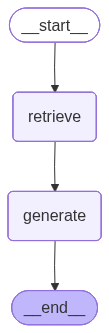

In [27]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [28]:
initial_state = {'query': query}
result = graph.invoke(initial_state)

In [29]:
result

{'query': '결혼하면 얼마를 받을 수 있을까?',
 'context': [Document(id='857bc704-0172-4d9a-b846-8b3ac0241e68', metadata={'producer': 'Microsoft: Print To PDF', 'creator': '', 'creationdate': '2026-01-16T00:25:28+09:00', 'source': '..\\data\\Employee_Benefits_Guide_2026_v1.pdf', 'file_path': '..\\data\\Employee_Benefits_Guide_2026_v1.pdf', 'total_pages': 22, 'format': 'PDF 1.7', 'title': 'Microsoft Word - Employee_Benefits_Guide_2026_v1.docx', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2026-01-16T00:25:28+09:00', 'trapped': '', 'modDate': "D:20260116002528+09'00'", 'creationDate': "D:20260116002528+09'00'", 'page': 18}, page_content='명세서의 ‘자격 수당’ 항목에서 확인 가능합니다. 축하금(200 만원)은 제출 후 2 주 이내 \n별도 입금됩니다. \nQ: 통근 버스를 놓쳤는데 택시비 지원이 되나요? A: 개인의 지각으로 인한 미탑승은 \n지원되지 않습니다. 단, 야근 등 업무상 사유로 막차(20:10) 이후 퇴근하거나, 버스 노선이 \n없는 지역으로 외근 시에는 ‘법인 카드’ 또는 ’교통비 영수증 청구’가 가능합니다. (팀장 \n전결 필요) \nQ: 사택(기숙사) 입주 조건은 어떻게 되나요? A: 원거리 거주자(회사 반경 40km 이외 지역 \n거주) 및 독신자 우선 배정입니다. 기혼자도 ‘주말 부부’ 등의 사유가 인정되면 입주 \n가능합니다. 월 관리비 5 만원

In [30]:
result['answer'].content

'결혼 축하금으로 200만원을 받을 수 있습니다. 이 금액은 제출 후 2주 이내에 별도로 입금됩니다.'